In [1]:
from func_parallel import run_model_test

import xarray as xr

import numpy as np

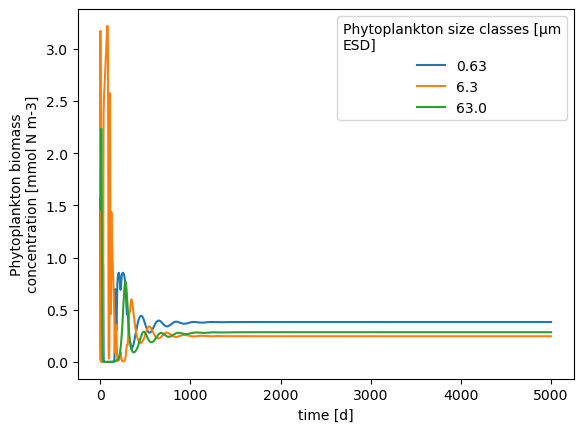

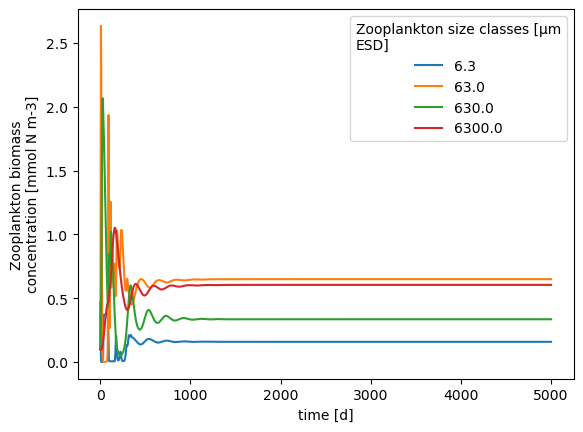

In [3]:
import matplotlib.pyplot as plt
out2 = run_model_test({'N0__value':0.00325,'GGE__gge':0.3103448275862069,'HigherOrderMortality__rate': 0.01120408})#.Phytoplankton__biomass.plot.line(x='time')
out2.Phytoplankton__biomass.plot.line(x='time')
plt.show()
out2.Zooplankton__biomass.plot.line(x='time')

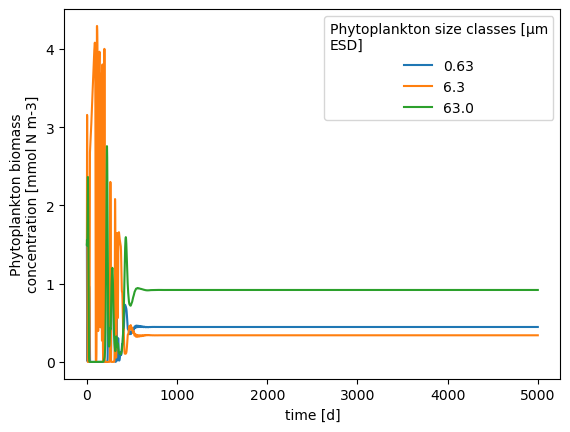

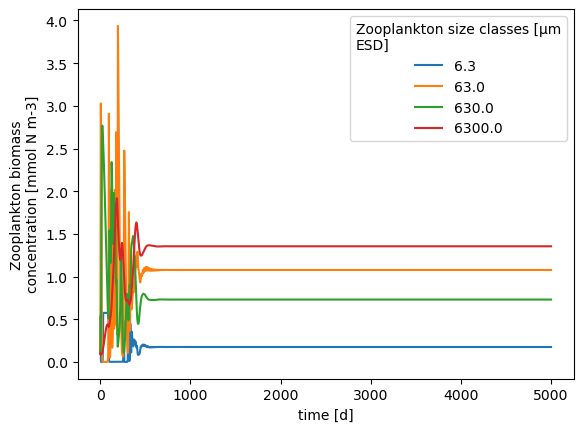

In [17]:
import matplotlib.pyplot as plt
outx = run_model_test({'GGE__gge':0.3705050505050505,'HigherOrderMortality__rate': 0.026118181818181818})#.Phytoplankton__biomass.plot.line(x='time')
outx.Phytoplankton__biomass.plot.line(x='time')
plt.show()
outx.Zooplankton__biomass.plot.line(x='time')

In [18]:
Phyto_init2 = out2.Phytoplankton__biomass.isel(time=slice(4000,5000)).mean(dim='time').values
Zoo_init2 = out2.Zooplankton__biomass.isel(time=slice(4000,5000)).mean(dim='time').values

In [19]:
Phyto_init = outx.Phytoplankton__biomass.isel(time=slice(4000,5000)).mean(dim='time').values
Zoo_init = outx.Zooplankton__biomass.isel(time=slice(4000,5000)).mean(dim='time').values

In [20]:
from func_parallel import model_setup_fs, model

In [21]:
input_pars = {'Phytoplankton__biomass_init':Phyto_init,
              'Zooplankton__biomass_init':Zoo_init,
    'GGE__gge':0.3705050505050505,'HigherOrderMortality__rate': 0.026118181818181818}

In [22]:
with model:
        model_out = model_setup_fs.xsimlab.update_vars(input_vars=input_pars).xsimlab.run()

InitState [0.         1.         0.44666331 0.3404672  0.91985636 0.17493329
 1.07698726 0.73048563 1.3544284 ]
[INFO] Steady state found with residual norm: 1.52176159714813e-12
Residuals: [ 0.00000000e+00  1.31084033e-12 -3.60905750e-13 -5.41178213e-13
 -4.17429979e-13  4.66293670e-15  3.63598041e-15  6.81399381e-15
  6.93889390e-18]
YSTEADY [0.         1.29192474 0.44666332 0.3404672  0.91985636 0.17493329
 1.07698726 0.73048563 1.3544284 ]


In [23]:
input_pars2 = {'Phytoplankton__biomass_init':Phyto_init2,
              'Zooplankton__biomass_init':Zoo_init2,
               'N0__value':0.00325,'GGE__gge':0.3103448275862069,'HigherOrderMortality__rate': 0.01120408}

with model:
        model_out2 = model_setup_fs.xsimlab.update_vars(input_vars=input_pars2).xsimlab.run()

InitState [0.         1.         0.38242593 0.24580962 0.28472762 0.15748729
 0.64883993 0.33438341 0.60412051]
[INFO] Steady state found with residual norm: 1.7678142681578257e-12
Residuals: [ 0.00000000e+00  7.49289519e-13 -7.34440286e-13  2.98455705e-13
 -1.24577085e-12 -7.02216063e-15  5.83179338e-13  2.07753953e-13
 -1.56125113e-17]
YSTEADY [0.         0.34597655 0.38242594 0.24580962 0.28472762 0.15748729
 0.64883993 0.33438341 0.60412052]


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

import matplotlib.dates as mdates
import datetime

In [25]:
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")

In [26]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

CARIACO.ui = CARIACO.ui.astype('category').cat.reorder_categories(['relaxed', 'weak','moderate', 'strong'])

CARIACO.upwelling = CARIACO.upwelling.astype('category').cat.reorder_categories(['relaxed', 'upwelling'])

In [27]:
# first split entire data frame by cluster time points from MS2

#GroupRed = extractGroups(year1="1996-01-01", year2="2003-12-31", year3="2014-01-01", year4="2016-12-31") #2016-12-31
#GroupBlue = extractGroups(year1="2004-01-01", year2="2013-12-31", year3="2017-06-01", year4="2017-12-31")

cluster1_mask = (CARIACO.date.dt.date>datetime.date(1996, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2003, 12, 31)) | \
                 (CARIACO.date.dt.date>datetime.date(2014, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2016, 12, 31))

cluster2_mask = (CARIACO.date.dt.date>datetime.date(2004, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2013, 12, 31))

CARIACO["cluster"] = 'none'
CARIACO.loc[cluster1_mask, "cluster"] = 'cluster 1'
CARIACO.loc[cluster2_mask, "cluster"] = 'cluster 2'

Text(0.5, 0, 'Cluster')

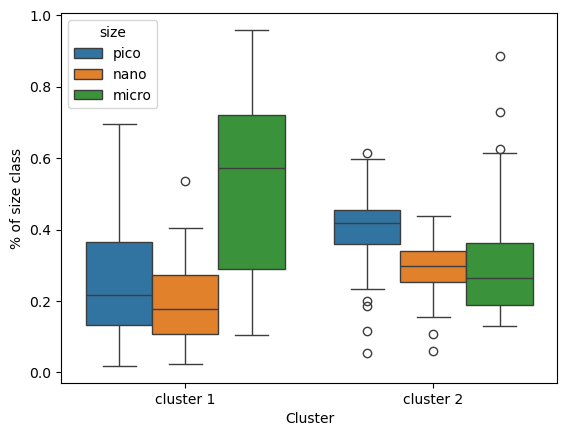

In [28]:
meltCar2 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('pico', 'nano', 'micro'), var_name='size')
sns.boxplot(data=meltCar2[meltCar2.cluster!='none'], x='cluster', y='value', hue='size')
plt.ylabel("% of size class")
plt.xlabel("Cluster")

Text(0.5, 0, 'Cluster')

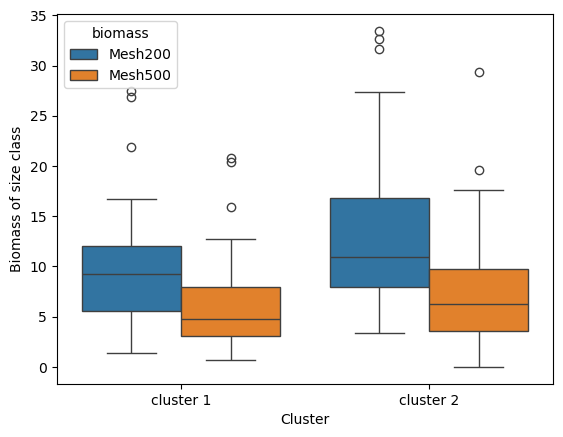

In [29]:
meltCar3 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('Mesh200', 'Mesh500'), var_name='biomass')
sns.boxplot(data=meltCar3[meltCar3.cluster!='none'], x='cluster', y='value', hue='biomass')
plt.ylabel("Biomass of size class")
plt.xlabel("Cluster")

In [31]:
phyto_out = model_out.isel(time=1).Phytoplankton__biomass 
percentage_phyto_out = (phyto_out / phyto_out.sum()) 

percentage_phyto_out

phyto_out2 = model_out2.isel(time=1).Phytoplankton__biomass 
percentage_phyto_out2 = (phyto_out2 / phyto_out2.sum()) 

percentage_phyto_out2

<xarray.DataArray 'Phytoplankton__biomass' (phyto: 3)> Size: 24B
array([0.41888429, 0.26924374, 0.31187196])
Coordinates:
  * phyto    (phyto) float64 24B 0.63 6.3 63.0
    time     float64 8B 0.0

In [32]:
percentage_zoo_out

NameError: name 'percentage_zoo_out' is not defined

In [35]:
zoo_out = model_out.isel(time=1).Zooplankton__biomass 
percentage_zoo_out = (zoo_out / zoo_out.sum()) 

Mesh200 = (percentage_zoo_out[0]+percentage_zoo_out[1]).values.max()

Mesh500 = percentage_zoo_out[2].values.max()

In [36]:
zoo_out2 = model_out2.isel(time=1).Zooplankton__biomass 
percentage_zoo_out2 = (zoo_out2 / zoo_out2.sum()) 

Mesh2002 = (percentage_zoo_out2[0]+percentage_zoo_out2[1]).values.max()

Mesh5002 = percentage_zoo_out2[2].values.max()

In [37]:
Mesh200.max()

np.float64(0.3751820823503733)

In [38]:
Phyto_init / Phyto_init.sum()

array([0.26166769, 0.19945508, 0.53887723])

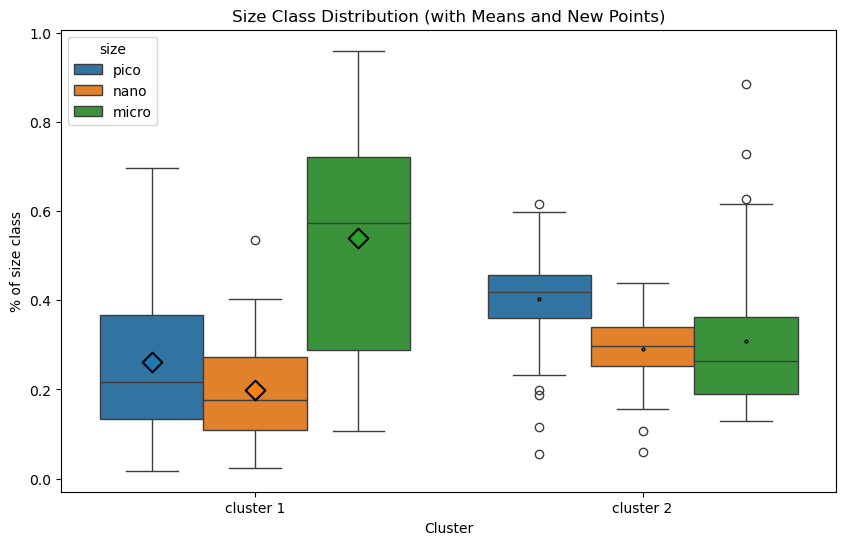

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. (Example Data) ---
# Create dummy data for the boxplot

# Create your new points (for cluster 1)
df_new_points = pd.DataFrame({
    'cluster': 'cluster 1',
    'value': percentage_phyto_out,
    'size': ['pico', 'nano', 'micro']
})

# --- 2. (Plotting) ---
plt.figure(figsize=(10, 6))

# --- Plot your original boxplot, NOW WITH MEANS ---
ax = sns.boxplot(
    data=meltCar2[meltCar2.cluster!='none'], 
    x='cluster', 
    y='value', 
    hue='size',
    showmeans=True,  # Show the mean
    meanprops={"marker":"o", "markerfacecolor":"grey", 
               "markeredgecolor":"black", "markersize":"2"} # Style it
)

# --- Overlay your new points (from previous step) ---
sns.stripplot(
    data=df_new_points,
    x='cluster',
    y='value',
    hue='size',
    ax=ax,            
    dodge=True,       
    jitter=False,     
    marker='D',       # Diamond marker
    size=10,          
    linewidth=1.5,
    edgecolor='black',  # Use a different color (e.g., red)
    facecolor='none'
)

# --- 3. (Cleanup) ---
handles, labels = ax.get_legend_handles_labels()
num_hues = len(meltCar2['size'].unique())
ax.legend(handles[0:num_hues], labels[0:num_hues], title='size')

plt.ylabel("% of size class")
plt.xlabel("Cluster")
plt.title("Size Class Distribution (with Means and New Points)")
plt.show()

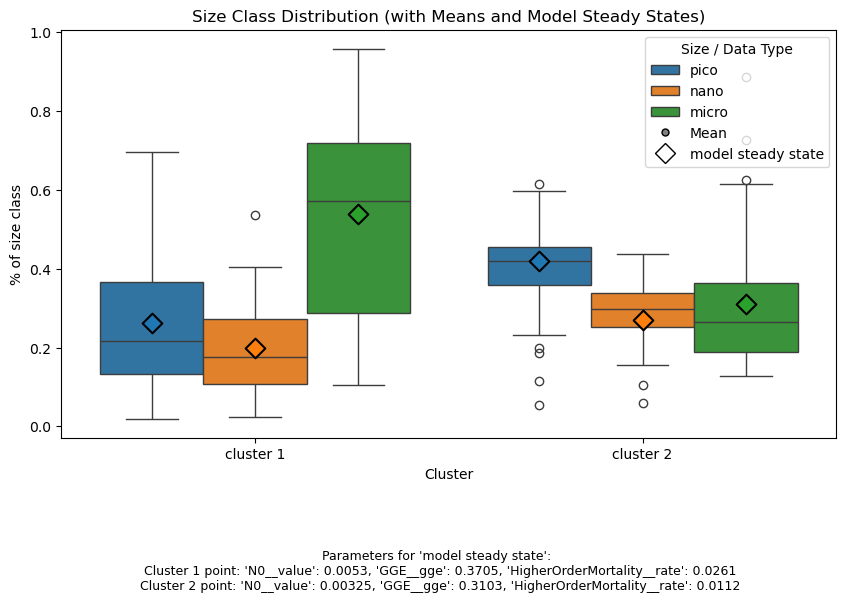

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D # Needed for custom legend handles

# --- 1. Prepare DataFrames ---
# (Assuming df_cluster1_points and df_cluster2_points are defined as before)
# ...

# --- Store Parameters for Caption ---
params_cluster1 = "'N0__value': 0.0053, 'GGE__gge': 0.3705, 'HigherOrderMortality__rate': 0.0261"
params_cluster2 = "'N0__value': 0.00325, 'GGE__gge': 0.3103, 'HigherOrderMortality__rate': 0.0112"

# --- 2. Plotting ---
plt.figure(figsize=(10, 6))

# --- Plot your original boxplot with means ---
ax = sns.boxplot(
    data=meltCar2[meltCar2.cluster != 'none'],
    x='cluster',
    y='value',
    hue='size',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"grey",
               "markeredgecolor":"black", "markersize":"2"}
)

# --- Overlay cluster 1 points ---
sns.stripplot(
    data=df_cluster1_points,
    x='cluster',
    y='value',
    hue='size',
    ax=ax,
    dodge=True,
    jitter=False,
    marker='D', # Diamond
    size=10,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    legend=False
)

# --- Overlay cluster 2 points (using the same marker) ---
sns.stripplot(
    data=df_cluster2_points,
    x='cluster',
    y='value',
    hue='size',
    ax=ax,
    dodge=True,
    jitter=False,
    marker='D', # Diamond
    size=10,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    legend=False
)

# --- 3. Custom Legend (Revised) ---
handles, labels = ax.get_legend_handles_labels()
num_hues = len(meltCar2['size'].unique())

# Handle for the mean
mean_handle = Line2D([0], [0], marker='o', color='w', label='Mean',
                     markerfacecolor='grey', markeredgecolor='black', markersize=5)

# --- Corrected Handle: Diamond marker labeled 'model steady state' ---
model_output_handle = Line2D([0], [0], marker='D', color='w', label='model steady state',
                             markerfacecolor='none', markeredgecolor='black', markersize=10)

# Combine handles/labels: Boxplot hues + Mean + Model Output
ax.legend(handles=handles[0:num_hues] + [mean_handle, model_output_handle], # Remove cluster2 handle
          labels=labels[0:num_hues] + ['Mean', 'model steady state'],     # Correct label
          title='Size / Data Type')

# --- 4. Final Touches & Caption ---
plt.ylabel("% of size class")
plt.xlabel("Cluster")
plt.title("Size Class Distribution (with Means and Model Steady States)") # Updated title

# Add caption below the plot
# Adjust parameter labels in caption to match legend
caption = f"Parameters for 'model steady state':\n  Cluster 1 point: {params_cluster1}\n  Cluster 2 point: {params_cluster2}"
plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=9)

plt.subplots_adjust(bottom=0.2) # Make space for the caption

plt.show()

Text(0.5, 0, 'Cluster')

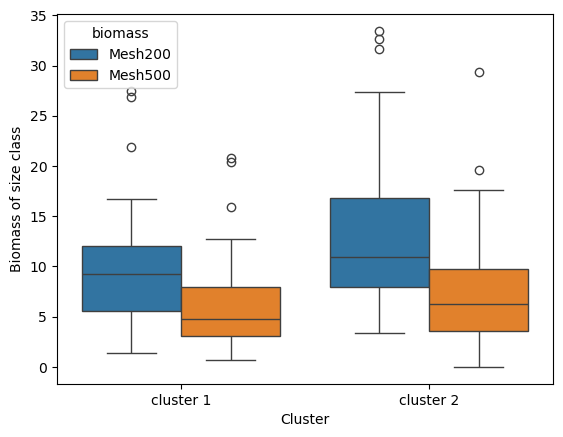

In [51]:
meltCar3 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('Mesh200', 'Mesh500'), var_name='biomass')
sns.boxplot(data=meltCar3[meltCar3.cluster!='none'], x='cluster', y='value', hue='biomass')
plt.ylabel("Biomass of size class")
plt.xlabel("Cluster")

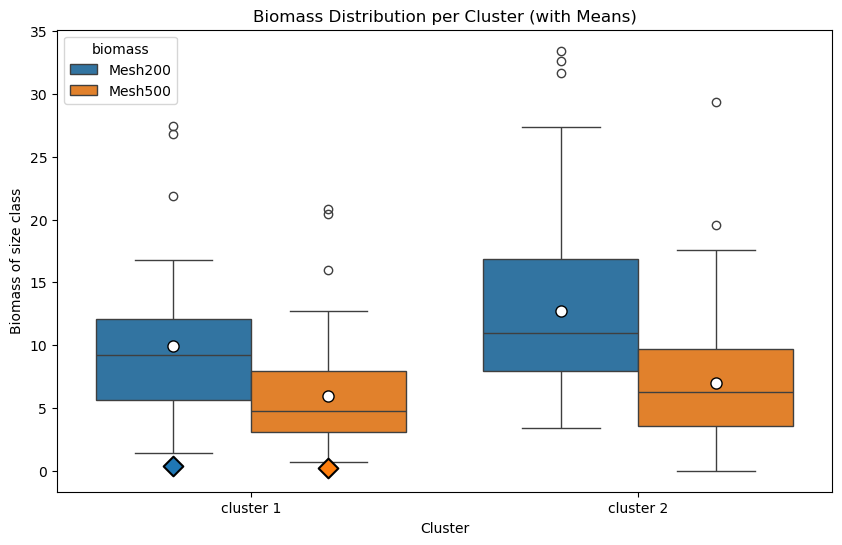

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Your Actual Data ---
#
# Make sure your 'meltCar3' DataFrame is defined before running the plot.
# meltCar3 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('Mesh200', 'Mesh500'), var_name='biomass')
#

# --- (OPTIONAL) Define new points to overlay ---
# To add the 'stripplot' points, you must first create a DataFrame
# for them, just like we did before.
#
# Example (replace with your real data):
# new_biomass_values = [150.5, 75.2] # Example values for Mesh200, Mesh500
# sizes = ['Mesh200', 'Mesh500']
# cluster_id = '1' # Or whichever cluster they belong to
#
# Create your new points (for cluster 1)
df_new_points = pd.DataFrame({
    'cluster': 'cluster 1',
    'value': [Mesh200, Mesh500],
    'size': ['Mesh200', 'Mesh500']
})

# --- 2. Plotting Code ---
plt.figure(figsize=(10, 6))

# --- Plot your new boxplot with means ---
ax = sns.boxplot(
    data=meltCar3[meltCar3.cluster!='none'], # Filter out 'none' cluster
    x='cluster', 
    y='value', 
    hue='biomass',   # Use 'biomass' for the hue
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", 
               "markeredgecolor":"black", "markersize":"8"}
)

# --- (OPTIONAL) Overlay your new points ---
# Uncomment the block below after you create 'df_new_biomass_points'
# --- Overlay your new points (from previous step) ---
sns.stripplot(
    data=df_new_points,
    x='cluster',
    y='value',
    hue='size',
    ax=ax,            
    dodge=True,       
    jitter=False,     
    marker='D',       # Diamond marker
    size=10,          
    linewidth=1.5,
    edgecolor='black',  # Use a different color (e.g., red)
    facecolor='none'
)

# --- 3. Clean up the legend ---
handles, labels = ax.get_legend_handles_labels()
# Get the number of hues (e.g., 2 for Mesh200, Mesh500)
num_hues = len(meltCar3['biomass'].unique())
# Show only one set of legend entries
ax.legend(handles[0:num_hues], labels[0:num_hues], title='biomass') # Set title to 'biomass'

# --- 4. Set new labels and title ---
plt.ylabel("Biomass of size class")
plt.xlabel("Cluster")
plt.title("Biomass Distribution per Cluster (with Means)")
plt.show()